# 🌳 Estrategia S7: Per-Client F1-Score + PCD

**Federated Proactive Forest - Estrategia de Agregación S7**

Este notebook demuestra el flujo completo de entrenamiento e inferencia utilizando la estrategia **S7: Per-Client F1-Score + PCD**, que ranking los árboles dentro de cada cliente independientemente por una combinación de F1-Score macro y PCD (Pairwise Concordance Diversity) e incorpora mediante round-robin con Progressive Forest early stopping.

## 📋 Contenido
1. Configuración inicial
2. Carga y preparación del dataset
3. Configuración del entrenamiento federado
4. Entrenamiento de bosques locales
5. Agregación con Ranking Per-Cliente por F1+PCD
6. Evaluación del modelo global
7. Predicción híbrida por cliente

## 1️⃣ Configuración Inicial

Importamos las librerías necesarias y configuramos el entorno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2️⃣ Carga y Preparación del Dataset

Cargamos el dataset `students_dropout.csv` y realizamos la preparación básica.

In [2]:
# Cargar dataset
df = pd.read_csv('../../../data/students_dropout.csv', sep=';')

print(f"📊 Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} características")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nDistribución de la variable objetivo:")
print(df['Target'].value_counts())

📊 Dataset cargado: 4424 muestras, 37 características

Columnas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unem

In [3]:
# Preparar características y variable objetivo
target_column = 'Target'
feature_columns = [col for col in df.columns if col != target_column]

# Separar features y target
X = df[feature_columns].values.astype(np.float64)
y = df[target_column].values

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)

print(f"\n✅ Features: {X.shape}")
print(f"✅ Labels codificados: {np.unique(y_encoded)}")
print(f"✅ Clases: {class_names}")


✅ Features: (4424, 36)
✅ Labels codificados: [0 1]
✅ Clases: ['Dropout', 'Enrolled']


In [4]:
# Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📈 Train: {X_train_scaled.shape[0]} muestras")
print(f"📉 Test: {X_test_scaled.shape[0]} muestras")


📈 Train: 3539 muestras
📉 Test: 885 muestras


## 3️⃣ Configuración del Entrenamiento Federado

Configuramos el orquestador FL con los hiperparámetros por defecto, la estrategia S7, y los pesos para F1 y PCD.

In [5]:
# Importar componentes del framework
import sys
sys.path.append('../../../')

from src.application.orchestrators import FLEXOrchestrator, DatasetSplit
from src.domain.aggregation.aggregation_factory import AggregationFactory

print("✅ Componentes importados correctamente")

✅ Componentes importados correctamente


In [6]:
# Configurar entrenamiento federado
config = {
    'n_clients': 5,              # Número de clientes
    'distribution': 'iid',        # Distribución IID
    'strategy': 'S7',             # Estrategia S7: Per-Client F1+PCD
    'n_estimators': 100,          # Número de árboles por cliente
    'alpha_pf': 0.1,              # Parámetro Proactive Forest
    'aggregation': {
        'f1_weight': 0.5,         # Peso para F1-Score
        'pcd_weight': 0.5         # Peso para PCD (Diversidad)
    },
    'verbose': False
}

# Crear DatasetSplit
dataset_split = DatasetSplit(
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_columns,
    class_names=class_names,
    dataset_name='Students Dropout'
)

# Crear orquestador
orchestrator = FLEXOrchestrator.from_config(config)

print("✅ Configuración completada")
print(f"   - Clientes: {config['n_clients']}")
print(f"   - Distribución: {config['distribution']}")
print(f"   - Estrategia: {config['strategy']} (Per-Client F1+PCD)")
print(f"   - Árboles por cliente: {config['n_estimators']}")
print(f"   - Peso F1-Score: {config['aggregation']['f1_weight']}")
print(f"   - Peso PCD: {config['aggregation']['pcd_weight']}")

✅ Configuración completada
   - Clientes: 5
   - Distribución: iid
   - Estrategia: S7 (Per-Client F1+PCD)
   - Árboles por cliente: 100
   - Peso F1-Score: 0.5
   - Peso PCD: 0.5


In [7]:
# Configurar federación
orchestrator.setup_federation(dataset_split, seed=42)

print("✅ Federación configurada")
print(f"   - Particiones de clientes: {list(orchestrator.client_partitions.keys())}")

✅ Federación configurada
   - Particiones de clientes: ['client_0', 'client_1', 'client_2', 'client_3', 'client_4']


## 4️⃣ Entrenamiento de Bosques Locales

Cada cliente entrena su bosque local Proactive Forest con sus propios datos.

In [8]:
# Ejecutar ronda federada completa
results = orchestrator.run_federated_round()

print("\n✅ Ronda federada completada")

DEBUG _train_local_forests client_0: y_pred_test sample=['Enrolled' 'Enrolled' 'Enrolled' 'Enrolled' 'Enrolled'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_0: y_test sample=[1 1 1 1 0] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_1: y_pred_test sample=['Enrolled' 'Enrolled' 'Enrolled' 'Enrolled' 'Enrolled'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_1: y_test sample=[1 1 1 1 0] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_2: y_pred_test sample=['Enrolled' 'Enrolled' 'Enrolled' 'Enrolled' 'Enrolled'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_2: y_test sample=[1 1 1 1 0] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_3: y_pred_test sample=['Enrolled' 'Enrolled' 'Enrolled' 'Enrolled' 'Enrolled'] type=<class 'numpy.str_'>
DEBUG _train_local_forests client_3: y_test sample=[1 1 1 1 0] type=<class 'numpy.int32'>
DEBUG _train_local_forests client_4: y_pred_test sample=['Enrolled' 'Enrolled' 'Enro

c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


...

[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)


c:\Users\Adrián Rodríguez\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\metrics\_classification.py:226: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


[ERROR] evaluate_local_pf_model_at_clients: Mix of label input types (string and number)

✅ Ronda federada completada


## 5️⃣ Agregación con Ranking Per-Cliente por F1+PCD

La estrategia S7 ranking los árboles dentro de cada cliente independientemente por una combinación de F1-Score y PCD (diversidad), luego incorpora mediante round-robin con Progressive Forest early stopping.

In [9]:
print("=" * 60)
print("📊 RESULTADOS DE AGREGACIÓN - S7 PER-CLIENT F1+PCD")
print("=" * 60)

print(f"\n🌳 Árboles en el bosque global: {results.n_trees_global}")
print(f"\n📈 Árboles seleccionados por cliente:")
for client_id, indices in results.selected_ids.items():
    print(f"   {client_id}: {len(indices)} árboles seleccionados")

📊 RESULTADOS DE AGREGACIÓN - S7 PER-CLIENT F1+PCD

🌳 Árboles en el bosque global: 19

📈 Árboles seleccionados por cliente:
   client_0: 4 árboles seleccionados
   client_1: 4 árboles seleccionados
   client_2: 4 árboles seleccionados
   client_3: 4 árboles seleccionados
   client_4: 3 árboles seleccionados


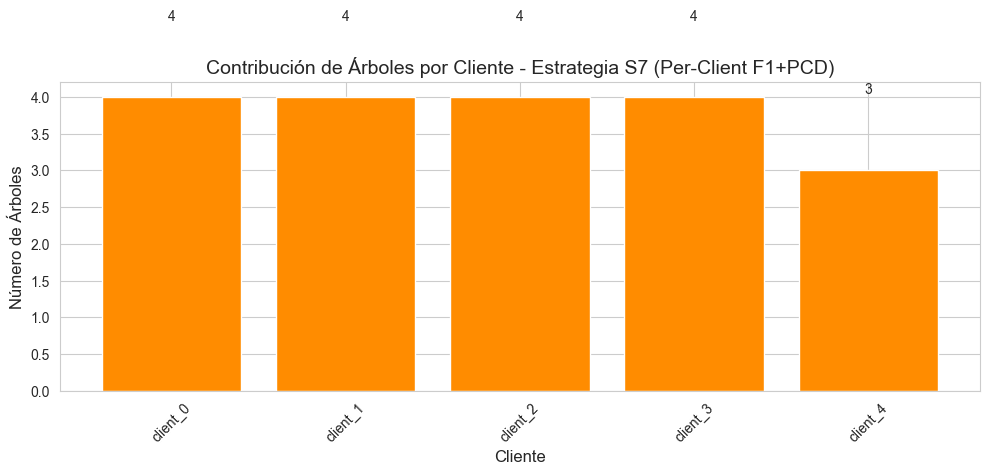

In [10]:
# Visualizar contribución de árboles por cliente
client_contributions = {cid: len(indices) for cid, indices in results.selected_ids.items()}

plt.figure(figsize=(10, 5))
bars = plt.bar(client_contributions.keys(), client_contributions.values(), color='darkorange')
plt.xlabel('Cliente', fontsize=12)
plt.ylabel('Número de Árboles', fontsize=12)
plt.title('Contribución de Árboles por Cliente - Estrategia S7 (Per-Client F1+PCD)', fontsize=14)
plt.xticks(rotation=45)

# Añadir etiquetas de valor
for bar, val in zip(bars, client_contributions.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Calcular score combinado F1+PCD para cada árbol y mostrar top 3 por cliente
f1_weight = config['aggregation']['f1_weight']
pcd_weight = config['aggregation']['pcd_weight']

if results.all_tree_entries and len(results.all_tree_entries) > 0:
    print("\n" + "=" * 60)
    print("🏆 TOP 3 ÁRBOLES POR F1+PCD POR CLIENTE")
    print("=" * 60)
    
    # Agrupar por cliente
    from collections import defaultdict
    client_entries = defaultdict(list)
    for entry in results.all_tree_entries:
        entry.combined_score = f1_weight * entry.macro_f1 + pcd_weight * entry.pcd
        client_entries[entry.client_id].append(entry)
    
    for client_id in sorted(client_entries.keys()):
        entries = client_entries[client_id]
        sorted_entries = sorted(entries, key=lambda e: e.combined_score, reverse=True)
        print(f"\n{client_id}:")
        print(f"  {'Rank':<6}{'Accuracy':<10}{'F1':<10}{'PCD':<10}{'Score':<10}")
        print(f"  {'-'*46}")
        for i, entry in enumerate(sorted_entries[:3], 1):
            print(f"  {i:<6}{entry.accuracy:<10.4f}{entry.macro_f1:<10.4f}{entry.pcd:<10.4f}{entry.combined_score:<10.4f}")


🏆 TOP 3 ÁRBOLES POR F1+PCD POR CLIENTE

client_0:
  Rank  Accuracy  F1        PCD       Score     
  ----------------------------------------------
  1     0.8542    0.8276    0.5525    0.6901    
  2     0.8542    0.8276    0.5525    0.6901    
  3     0.8542    0.8276    0.5525    0.6901    

client_1:
  Rank  Accuracy  F1        PCD       Score     
  ----------------------------------------------
  1     0.8508    0.8203    0.4757    0.6480    
  2     0.8508    0.8203    0.4757    0.6480    
  3     0.8508    0.8203    0.4757    0.6480    

client_2:
  Rank  Accuracy  F1        PCD       Score     
  ----------------------------------------------
  1     0.8497    0.8135    0.5243    0.6689    
  2     0.8497    0.8135    0.5243    0.6689    
  3     0.8497    0.8135    0.5243    0.6689    

client_3:
  Rank  Accuracy  F1        PCD       Score     
  ----------------------------------------------
  1     0.8565    0.8292    0.5401    0.6846    
  2     0.8565    0.8292    0.5401

## 6️⃣ Evaluación del Modelo Global

Evaluamos el rendimiento del bosque global en el conjunto de test.

In [12]:
print("=" * 60)
print("📊 MÉTRICAS DEL MODELO GLOBAL")
print("=" * 60)

print(f"\n🎯 Precisión (Accuracy): {results.global_accuracy:.4f}")
print(f"📊 F1-Score Macro: {results.global_macro_f1:.4f}")

# Obtener predicciones del reporte global
global_report = results.global_report
print(f"\n📈 Matriz de confusión:")
print(global_report.confusion_matrix)

📊 MÉTRICAS DEL MODELO GLOBAL

🎯 Precisión (Accuracy): 0.8497
📊 F1-Score Macro: 0.8195

📈 Matriz de confusión:
[[195  89]
 [ 44 557]]


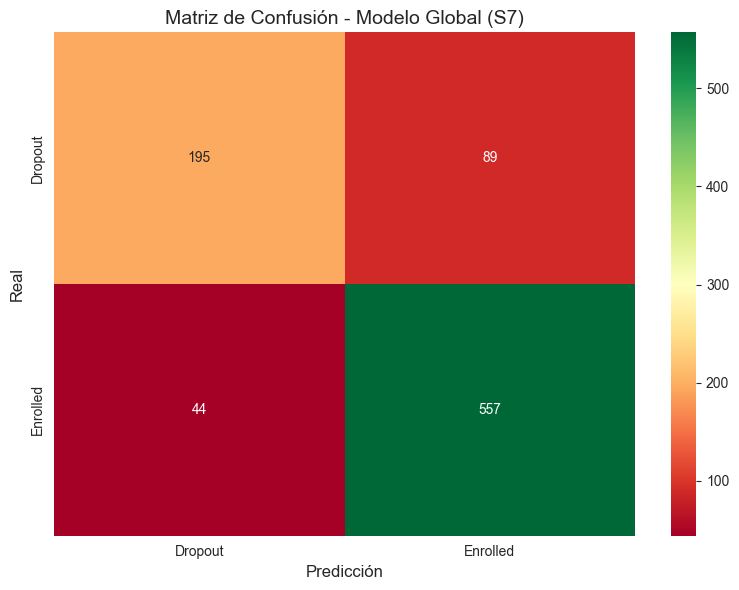

In [13]:
# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
cm = global_report.confusion_matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - Modelo Global (S7)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Reporte de clasificación detallado

print("\n" + "=" * 60)
print("📋 REPORTE DE CLASIFICACIÓN")
print("=" * 60)
print(f"Accuracy: {global_report.accuracy:.4f}")
print(f"F1-Score (Macro): {global_report.macro_f1:.4f}")
print(f"Precisión (Macro): {global_report.macro_precision:.4f}")
print(f"Recall (Macro): {global_report.macro_recall:.4f}")
print(f"\nF1-Score por clase:")
for cls, f1 in global_report.per_class_f1.items():
    print(f"   {cls}: {f1:.4f}")
print(f"\nPrecisión por clase:")
for cls, prec in global_report.per_class_prec.items():
    print(f"   {cls}: {prec:.4f}")
print(f"\nRecall por clase:")
for cls, rec in global_report.per_class_recall.items():
    print(f"   {cls}: {rec:.4f}")


📋 REPORTE DE CLASIFICACIÓN
Accuracy: 0.8497
F1-Score (Macro): 0.8195
Precisión (Macro): 0.8391
Recall (Macro): 0.8067

F1-Score por clase:
   Dropout: 0.7457
   Enrolled: 0.8933

Precisión por clase:
   Dropout: 0.8159
   Enrolled: 0.8622

Recall por clase:
   Dropout: 0.6866
   Enrolled: 0.9268


## 7️⃣ Predicción Híbrida por Cliente

Cada cliente utiliza una combinación de su bosque local y el bosque global (excluyendo sus propios árboles) para realizar predicciones.

In [15]:
print("=" * 60)
print("📊 MÉTRICAS DE PREDICCIÓN HÍBRIDA POR CLIENTE")
print("=" * 60)

for client_id in results.client_ids:
    print(f"\n{client_id}:")
    print(f"   - Accuracy local: {results.client_accuracies[client_id]:.4f}")
    print(f"   - F1-Score local: {results.client_f1_scores[client_id]:.4f}")
    print(f"   - Tamaño del bosque híbrido: {results.client_hybrid_forest_sizes[client_id]} árboles")

📊 MÉTRICAS DE PREDICCIÓN HÍBRIDA POR CLIENTE

client_0:
   - Accuracy local: 0.8542
   - F1-Score local: 0.8276
   - Tamaño del bosque híbrido: 39 árboles

client_1:
   - Accuracy local: 0.8508
   - F1-Score local: 0.8203
   - Tamaño del bosque híbrido: 39 árboles

client_2:
   - Accuracy local: 0.8497
   - F1-Score local: 0.8135
   - Tamaño del bosque híbrido: 42 árboles

client_3:
   - Accuracy local: 0.8565
   - F1-Score local: 0.8292
   - Tamaño del bosque híbrido: 111 árboles

client_4:
   - Accuracy local: 0.8678
   - F1-Score local: 0.8412
   - Tamaño del bosque híbrido: 54 árboles


In [16]:
# Calcular métricas de predicción híbrida por cliente
print("\n" + "=" * 60)
print("📈 PRECISIÓN POR CLIENTE (Predicción Híbrida)")
print("=" * 60)

client_accuracies = {}
client_f1_scores = {}

for client_id, hybrid_preds in results.client_hybrid_predictions.items():
    acc = accuracy_score(results.y_test, hybrid_preds)
    f1 = f1_score(results.y_test, hybrid_preds, average='macro', zero_division=0)
    client_accuracies[client_id] = acc
    client_f1_scores[client_id] = f1
    print(f"{client_id}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")


📈 PRECISIÓN POR CLIENTE (Predicción Híbrida)
client_0: Accuracy = 0.8576, F1-Score = 0.8284
client_1: Accuracy = 0.8565, F1-Score = 0.8269
client_2: Accuracy = 0.8497, F1-Score = 0.8175
client_3: Accuracy = 0.8554, F1-Score = 0.8265
client_4: Accuracy = 0.8576, F1-Score = 0.8296


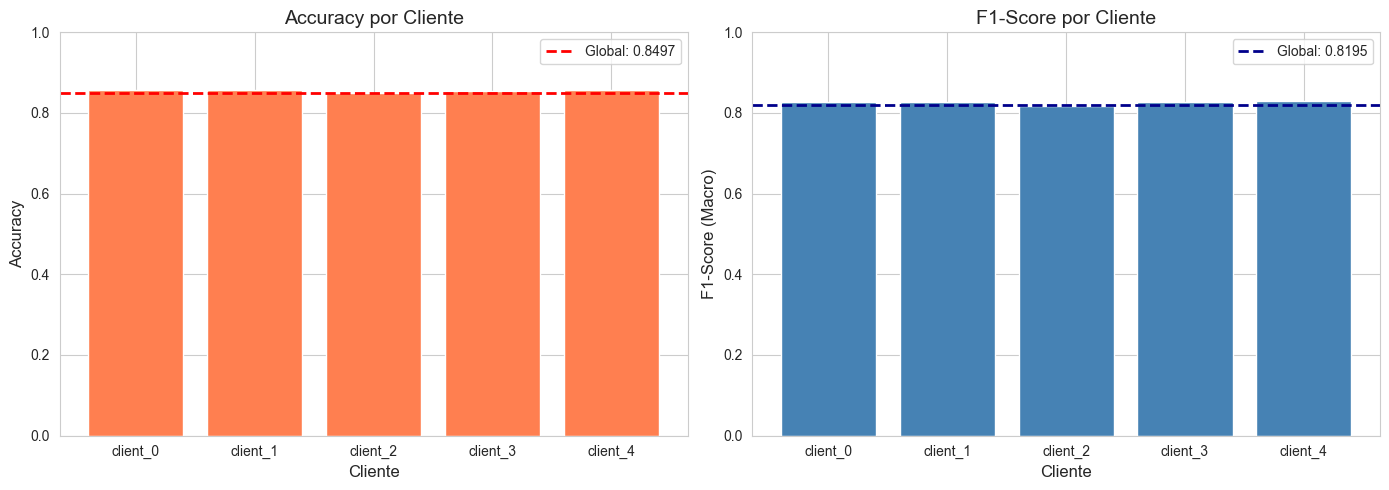

In [17]:
# Visualizar métricas por cliente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy por cliente
ax1 = axes[0]
bars1 = ax1.bar(client_accuracies.keys(), client_accuracies.values(), color='coral')
ax1.axhline(y=results.global_accuracy, color='red', linestyle='--', linewidth=2, 
            label=f'Global: {results.global_accuracy:.4f}')
ax1.set_xlabel('Cliente', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy por Cliente', fontsize=14)
ax1.legend()
ax1.set_ylim(0, 1)

# F1-Score por cliente
ax2 = axes[1]
bars2 = ax2.bar(client_f1_scores.keys(), client_f1_scores.values(), color='steelblue')
ax2.axhline(y=results.global_macro_f1, color='darkblue', linestyle='--', linewidth=2,
            label=f'Global: {results.global_macro_f1:.4f}')
ax2.set_xlabel('Cliente', fontsize=12)
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score por Cliente', fontsize=14)
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 📊 Resumen Final

Comparativa completa de todos los resultados.

In [18]:
# Crear resumen completo
summary_df = pd.DataFrame({
    'Cliente': list(client_accuracies.keys()),
    'Accuracy Local': [results.client_accuracies[cid] for cid in client_accuracies.keys()],
    'F1 Local': [results.client_f1_scores[cid] for cid in client_f1_scores.keys()],
    'Accuracy Híbrido': list(client_accuracies.values()),
    'F1 Híbrido': list(client_f1_scores.values()),
    'Tamaño Bosque': [results.client_hybrid_forest_sizes[cid] for cid in client_accuracies.keys()]
})

# Añadir fila global
summary_df.loc[len(summary_df)] = ['GLOBAL', results.global_accuracy, results.global_macro_f1, 
                                    results.global_accuracy, results.global_macro_f1, 
                                    results.n_trees_global]

print("\n" + "=" * 80)
print("📋 RESUMEN COMPLETO - ESTRATEGIA S7 PER-CLIENT F1+PCD")
print("=" * 80)
print(summary_df.to_string(index=False))


📋 RESUMEN COMPLETO - ESTRATEGIA S7 PER-CLIENT F1+PCD
 Cliente  Accuracy Local  F1 Local  Accuracy Híbrido  F1 Híbrido  Tamaño Bosque
client_0        0.854237  0.827577          0.857627    0.828446             39
client_1        0.850847  0.820277          0.856497    0.826890             39
client_2        0.849718  0.813500          0.849718    0.817467             42
client_3        0.856497  0.829163          0.855367    0.826498            111
client_4        0.867797  0.841233          0.857627    0.829585             54
  GLOBAL        0.849718  0.819521          0.849718    0.819521             19


C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 9878 (\N{SCALES}) missing from current font.
  plt.tight_layout()
C:\Users\Adrián Rodríguez\AppData\Local\Temp\ipykernel_2588\2300623837.py:59: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from curre

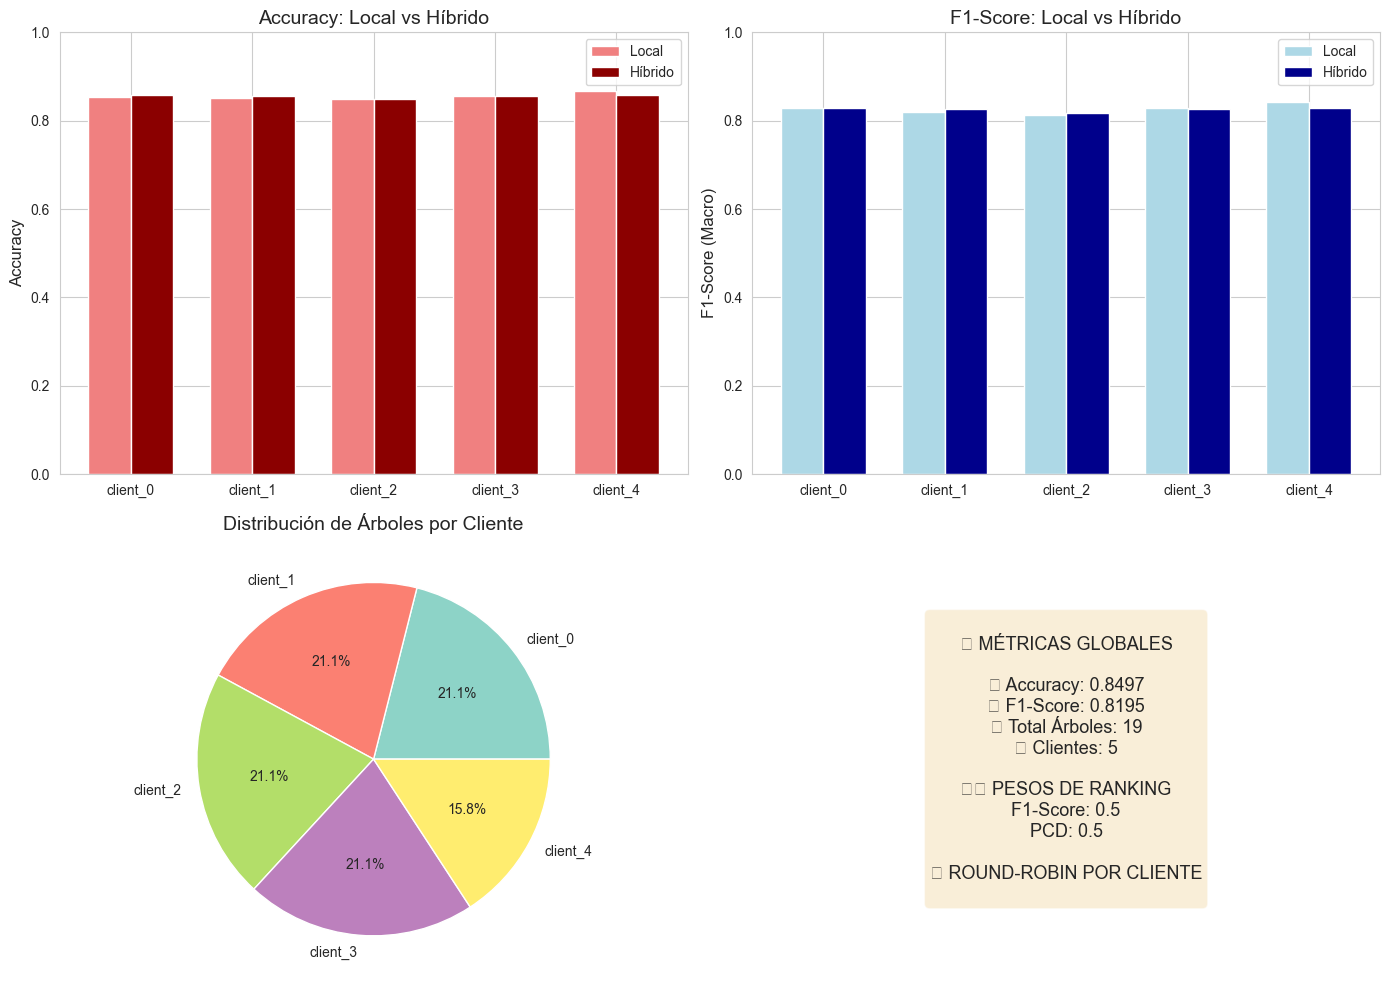

In [19]:
# Visualización comparativa final
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparativa Accuracy Local vs Híbrido
ax1 = axes[0, 0]
x = np.arange(len(client_accuracies))
width = 0.35
local_acc = [results.client_accuracies[cid] for cid in client_accuracies.keys()]
hybrid_acc = list(client_accuracies.values())
ax1.bar(x - width/2, local_acc, width, label='Local', color='lightcoral')
ax1.bar(x + width/2, hybrid_acc, width, label='Híbrido', color='darkred')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy: Local vs Híbrido', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(client_accuracies.keys())
ax1.legend()
ax1.set_ylim(0, 1)

# 2. Comparativa F1-Score Local vs Híbrido
ax2 = axes[0, 1]
local_f1 = [results.client_f1_scores[cid] for cid in client_f1_scores.keys()]
hybrid_f1 = list(client_f1_scores.values())
ax2.bar(x - width/2, local_f1, width, label='Local', color='lightblue')
ax2.bar(x + width/2, hybrid_f1, width, label='Híbrido', color='darkblue')
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_title('F1-Score: Local vs Híbrido', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(client_accuracies.keys())
ax2.legend()
ax2.set_ylim(0, 1)

# 3. Distribución de árboles
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(results.selected_ids)))
ax3.pie([len(results.selected_ids[cid]) for cid in results.selected_ids.keys()],
        labels=results.selected_ids.keys(), autopct='%1.1f%%', colors=colors)
ax3.set_title('Distribución de Árboles por Cliente', fontsize=14)

# 4. Métricas globales y pesos
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = f"""
📊 MÉTRICAS GLOBALES

🎯 Accuracy: {results.global_accuracy:.4f}
📊 F1-Score: {results.global_macro_f1:.4f}
🌳 Total Árboles: {results.n_trees_global}
👥 Clientes: {len(results.client_ids)}

⚖️ PESOS DE RANKING
F1-Score: {f1_weight}
PCD: {pcd_weight}

🔄 ROUND-ROBIN POR CLIENTE
"""
ax4.text(0.5, 0.5, metrics_text, fontsize=13, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## ✅ Conclusiones

La estrategia **S7: Per-Client F1+PCD** utiliza un enfoque de ranking por cliente balanceado:

1. **Ranking independiente por cliente**: Cada cliente ranking sus árboles por una combinación de F1-Score y PCD
2. **Balance rendimiento-diversidad**: El score combinado equilibra precisión (F1) y diversidad (PCD)
3. **Round-robin**: Los árboles se incorporan por turnos rotativos (un árbol de cada cliente por episodio)
4. **Early stopping**: Progressive Forest detiene la agregación cuando converge

**Ventajas:**
- Representación equitativa de todos los clientes
- Balance óptimo entre rendimiento y diversidad del ensemble
- La diversidad (PCD) ayuda a prevenir sobreajuste
- Ideal para datasets desbalanceados
- Configurable mediante pesos F1/PCD

**Desventajas:**
- Más compleja de configurar (seleccionar pesos óptimos)
- El cálculo de PCD añade overhead computacional
- Puede incluir árboles de menor calidad de clientes débiles

## 🔧 Experimentación con Pesos

Puedes experimentar con diferentes combinaciones de pesos para F1 y PCD:

In [20]:
# Ejemplos de configuraciones de pesos
weight_configs = [
    {'f1_weight': 0.5, 'pcd_weight': 0.5},  # Balanceado (por defecto)
    {'f1_weight': 0.7, 'pcd_weight': 0.3},  # Priorizar F1
    {'f1_weight': 0.3, 'pcd_weight': 0.7},  # Priorizar Diversidad
    {'f1_weight': 1.0, 'pcd_weight': 0.0},  # Solo F1 (equivalente a S6)
    {'f1_weight': 0.0, 'pcd_weight': 1.0},  # Solo Diversidad
]

print("Configuraciones de pesos sugeridas:")
print("=" * 50)
for i, cfg in enumerate(weight_configs, 1):
    print(f"{i}. F1: {cfg['f1_weight']:.1f}, PCD: {cfg['pcd_weight']:.1f}")

Configuraciones de pesos sugeridas:
1. F1: 0.5, PCD: 0.5
2. F1: 0.7, PCD: 0.3
3. F1: 0.3, PCD: 0.7
4. F1: 1.0, PCD: 0.0
5. F1: 0.0, PCD: 1.0


## 📈 Comparativa S7 vs S6

La principal diferencia entre S7 y S6 es el criterio de ranking:

| Estrategia | Criterio de Ranking | Ventaja Principal |
|------------|---------------------|-------------------|
| **S6** | Solo F1-Score | Máxima precisión por clase |
| **S7** | F1-Score + PCD | Balance precisión-diversidad |

**¿Cuándo usar cada una?**
- **S6**: Cuando la precisión es lo más importante y tienes datos balanceados
- **S7**: Cuando quieres prevenir sobreajuste y mejorar generalización